In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [3]:
df = pd.read_csv('baseline_numbers.csv.tmp')

In [110]:
methods = sorted(np.unique(df.method.values))
methods = [m for m in methods if len(df[df.method==m])==7]
datasets = sorted(np.unique(df.benchmark.values))
scores = [s for s in sorted(df.columns) if s not in ['benchmark', 'method'] and 'std' not in s]

print(scores)


['auc_mean', 'auprc_mean', 'f1_mean']


In [111]:
score = scores[1]
results_array = np.zeros([len(datasets), len(methods)])
for i, method in enumerate(methods):
    for j, dataset in enumerate(datasets):
        value = df[(df.method==method) & (df.benchmark==dataset)][score]
        if len(value) >0:
            results_array[j, i] = value

/tmp/ipykernel_855382/3656295317.py:7: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  results_array[j, i] = value


(<Figure size 600x310 with 1 Axes>, <Axes: >)

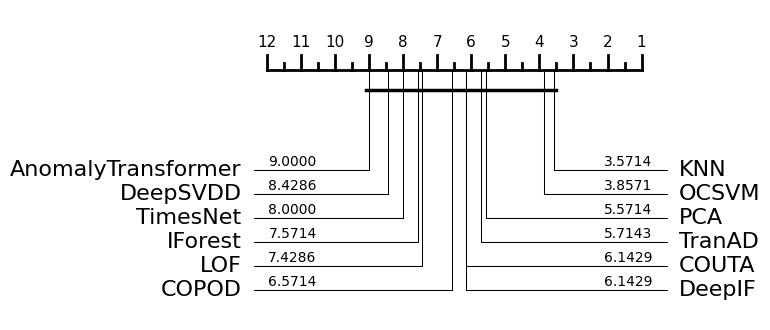

In [112]:
plot_critical_difference(results_array, methods, alpha=0.1)